# Movie Recommendation — Anshika
Predicting whether a movie should be recommended, using `anshika_movie_dataset.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('anshika_movie_dataset.csv')
df

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
0,1,sci-fi,french,96,40.6,60.8,2014,0,0
1,2,comedy,english,128,55.5,83.8,2010,0,1
2,3,horror,french,156,44.2,74.8,2022,1,0
3,4,comedy,korean,89,40.7,72.6,2009,0,1
4,5,horror,spanish,153,38.7,41.7,2011,1,0
...,...,...,...,...,...,...,...,...,...
595,596,horror,english,115,67.7,72.0,2003,0,0
596,597,comedy,hindi,101,51.0,52.8,2011,1,0
597,598,comedy,french,167,46.0,52.9,2018,1,0
598,599,thriller,spanish,100,82.6,77.7,2012,1,1


In [2]:
df.shape

(600, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   movie_id        600 non-null    int64  
 1   genre           600 non-null    str    
 2   language        600 non-null    str    
 3   runtime_min     600 non-null    int64  
 4   critic_score    600 non-null    float64
 5   audience_score  600 non-null    float64
 6   release_year    600 non-null    int64  
 7   num_awards      600 non-null    int64  
 8   recommend       600 non-null    int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 49.8 KB


In [4]:
df.describe()

,movie_id,runtime_min,critic_score,audience_score,release_year,num_awards,recommend
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000
mean,300.500000,130.575000,60.322833,64.326667,2009.173333,1.14500,0.590000
std,173.349358,28.555444,17.034266,14.952949,8.126296,1.07668,0.492244
min,1.000000,80.000000,4.700000,24.300000,1995.000000,0.00000,0.000000
25%,150.750000,106.000000,48.400000,53.850000,2003.000000,0.00000,0.000000
50%,300.500000,132.000000,60.600000,63.700000,2009.000000,1.00000,1.000000
75%,450.250000,155.000000,71.600000,74.650000,2016.000000,2.00000,1.000000
max,600.000000,179.000000,100.000000,100.000000,2023.000000,6.00000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

movie_id          0
genre             0
language          0
runtime_min       0
critic_score      0
audience_score    0
release_year      0
num_awards        0
recommend         0
dtype: int64

## Exploratory data analysis

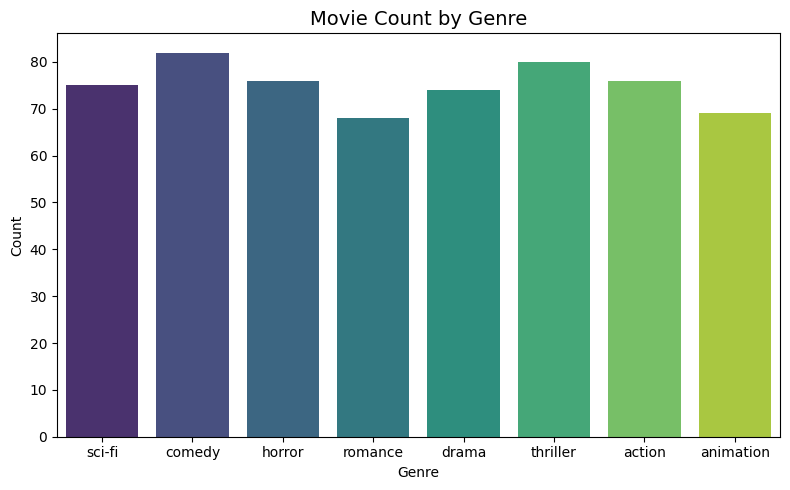

In [7]:
# how many movies per genre
plt.figure(figsize=(8, 5))
sns.countplot(x='genre', data=df, palette='viridis')
plt.title('Movie Count by Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

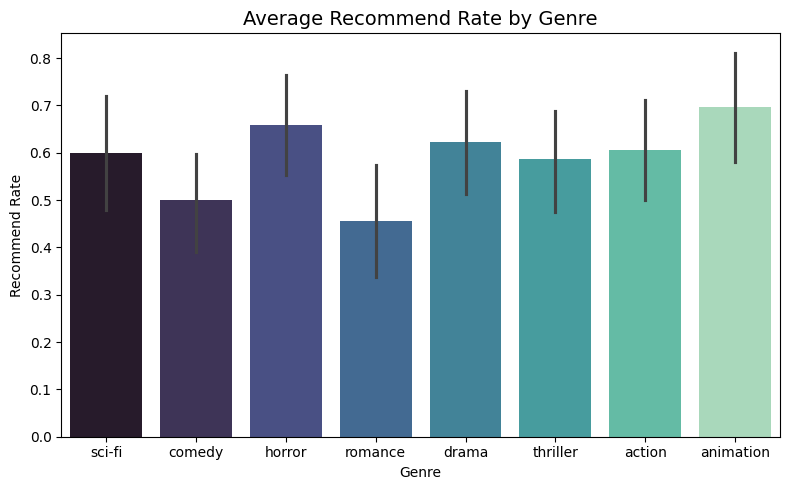

In [8]:
# recommend rate per genre - which genres get recommended more
plt.figure(figsize=(8, 5))
sns.barplot(x='genre', y='recommend', data=df, palette='mako')
plt.title('Average Recommend Rate by Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Recommend Rate')
plt.tight_layout()
plt.show()

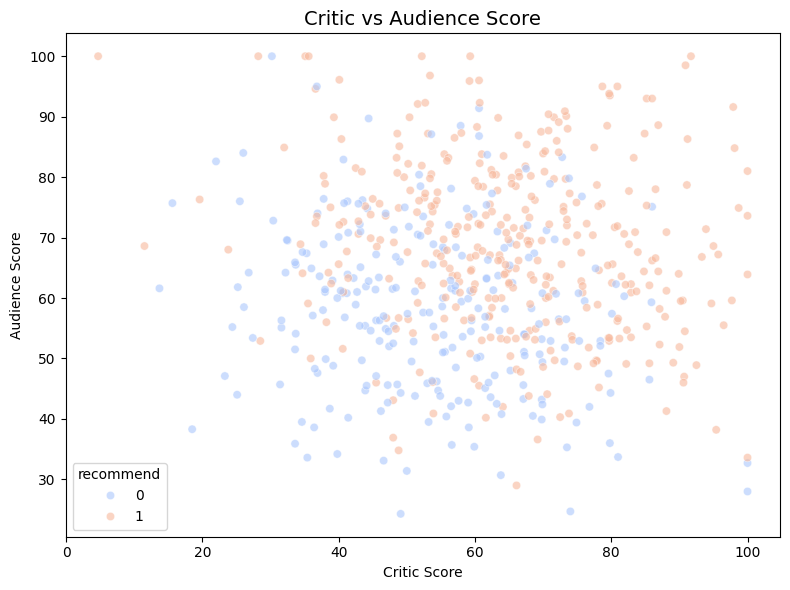

In [9]:
# critic vs audience score, colored by recommend label
plt.figure(figsize=(8, 6))
sns.scatterplot(x='critic_score', y='audience_score', hue='recommend', data=df, palette='coolwarm', alpha=0.6)
plt.title('Critic vs Audience Score', fontsize=14)
plt.xlabel('Critic Score')
plt.ylabel('Audience Score')
plt.tight_layout()
plt.show()

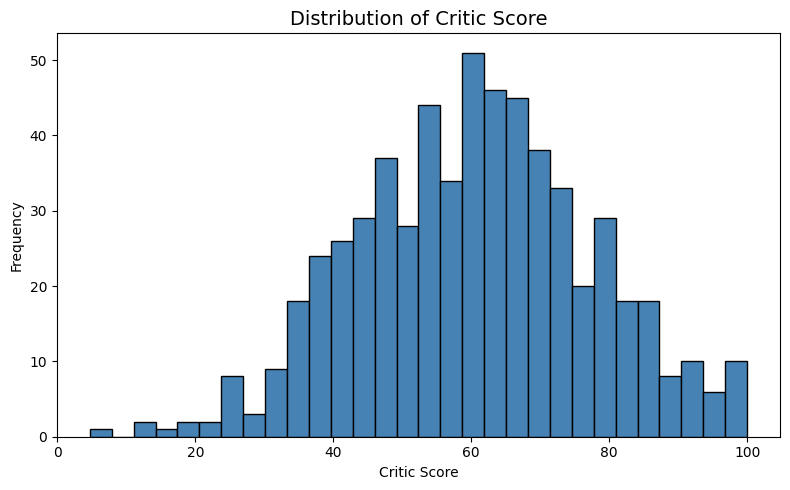

In [10]:
# spread of critic score
plt.figure(figsize=(8, 5))
plt.hist(df['critic_score'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Critic Score', fontsize=14)
plt.xlabel('Critic Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Feature engineering

In [11]:
## FEATURE ENGINEERING
# average of critic and audience score - single quality signal
df['avg_score'] = (df['critic_score'] + df['audience_score']) / 2
# bucket release year into decade
df['decade'] = (df['release_year'] // 10) * 10
# flag for movies that have won at least one award
df['is_award_winner'] = (df['num_awards'] > 0).astype(int)
# how far the critic and audience disagree
df['score_gap'] = (df['critic_score'] - df['audience_score']).abs()
df.head()

,movie_id,genre,language,runtime_min,critic_score,audience_score,release_year,num_awards,recommend,avg_score,decade,is_award_winner,score_gap
0,1,sci-fi,french,96,40.6,60.8,2014,0,0,50.70,2010,0,20.2
1,2,comedy,english,128,55.5,83.8,2010,0,1,69.65,2010,0,28.3
2,3,horror,french,156,44.2,74.8,2022,1,0,59.50,2020,1,30.6
3,4,comedy,korean,89,40.7,72.6,2009,0,1,56.65,2000,0,31.9
4,5,horror,spanish,153,38.7,41.7,2011,1,0,40.20,2010,1,3.0


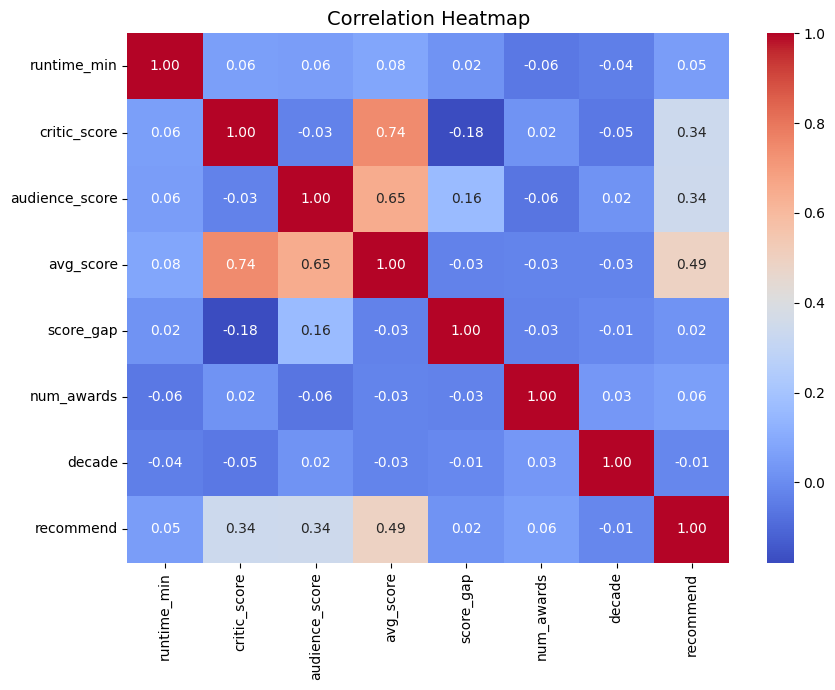

In [12]:
# correlation heatmap of numeric features including the new ones
plt.figure(figsize=(9, 7))
num_cols = ['runtime_min', 'critic_score', 'audience_score', 'avg_score', 'score_gap', 'num_awards', 'decade', 'recommend']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['genre'] = le.fit_transform(df['genre'])
df['language'] = le.fit_transform(df['language'])

## Recommendation target — is this movie worth recommending?

In [14]:
df['recommend'].value_counts()

recommend
1    354
0    246
Name: count, dtype: int64

In [15]:
X = df.drop(['recommend'], axis=1)
y = df['recommend']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## SVM classifier (SVC)

In [17]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.6833333333333333


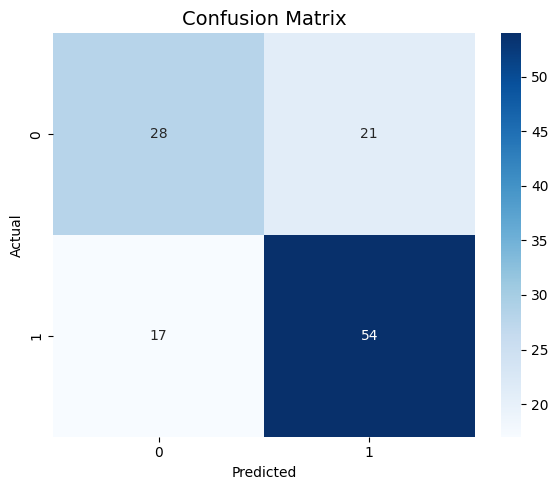

In [19]:
# confusion matrix - simple view of where the model gets it right/wrong
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()